In [138]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
 

In [114]:
df=pd.read_csv("loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


handle Missing values


In [115]:
#to categoricals the data we can do it as a 
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["float"]).columns

In [116]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [117]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [118]:
#simpleLmputer
#for completing missing values with simple strategies

from sklearn.impute import SimpleImputer
num_imp=SimpleImputer(strategy='mean')
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])


In [119]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [120]:
cat_imp=SimpleImputer(strategy='most_frequent')
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [121]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


EDA - exploratory data analysis


Text(0.5, 1.0, 'Is Laon approved or not')

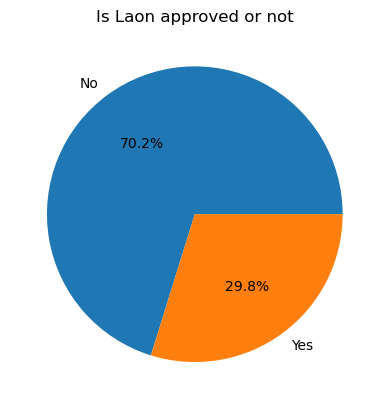

In [122]:
#how balance the class are
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is Laon approved or not")

[Text(0, 0, '621'), Text(0, 0, '379')]

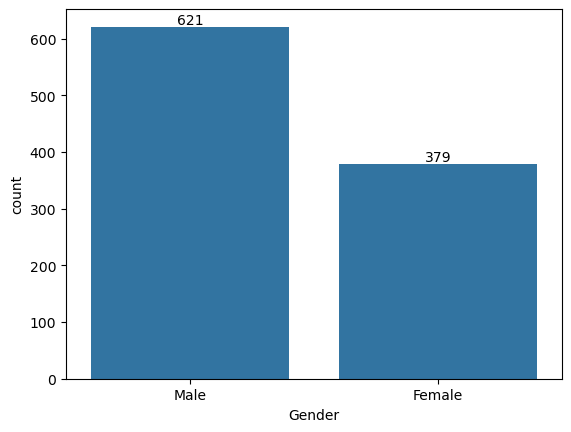

In [123]:
# analyze categories

gender_cnt=df["Gender"].value_counts()
 

ax=sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

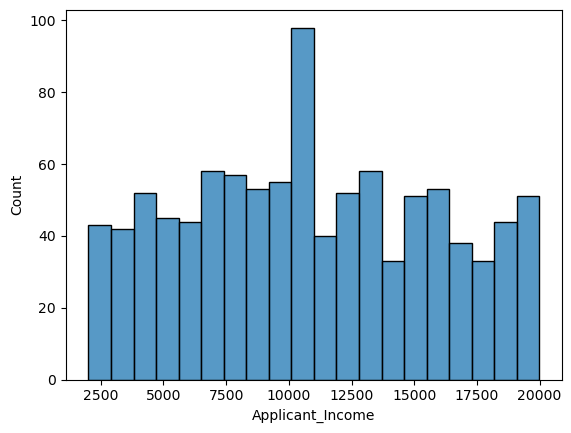

In [124]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

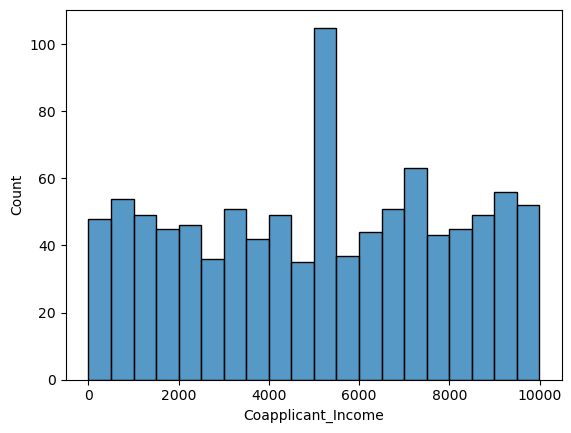

In [125]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)


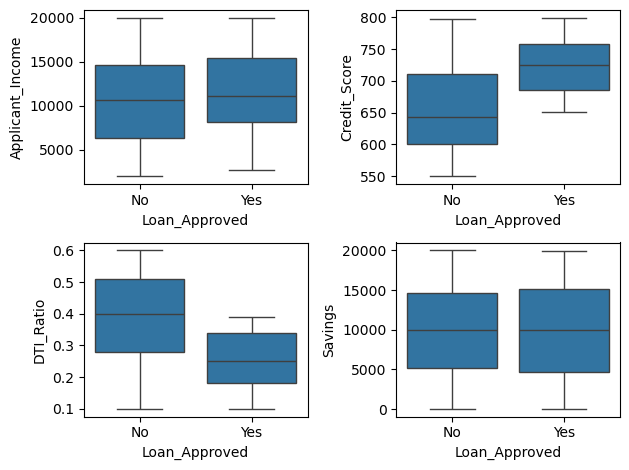

In [126]:
fig,axes=plt.subplots(2,2)

sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

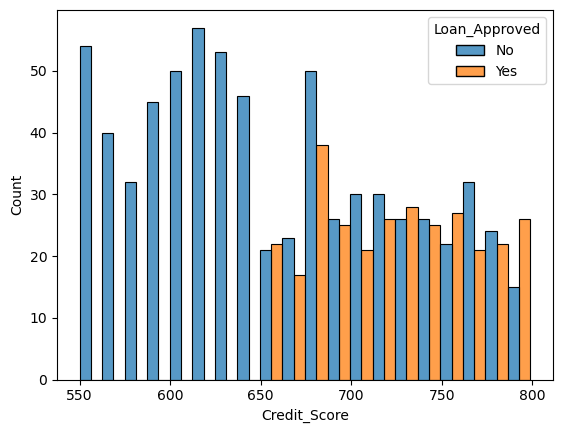

In [127]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
    
)

In [128]:
#revmove the applicant id beacuse it does not provide any nesscary information in our data sets
df=df.drop("Applicant_ID",axis=1)

In [129]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

feature encoding

Encoding


1.labelEncoder-Assigns an interger to each category --used when ordinal data(data has some order)


2.OneHotEncoding-Create binary columns for each category --used when nominal(no order)


for this particular we are going to use the sklearn


In [130]:
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()

# Encode the education level column
df["Education_Level"] = le.fit_transform(df["Education_Level"])

# Corrected the column name typo here
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
 

In [147]:
from sklearn.preprocessing import OneHotEncoder

cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category" ]

ohe= OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")

encoded= ohe.fit_transform(df[cols])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)

df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

correlation Heatmap

it is a visual representation of the relationship between numericsl variable in the datasets

it showa correlation coefficent(r) between two numeric variables

range from -1 to 1

1 is the perfect positive correlation 

-1 is the perfect negative correlation

0 is nonlinear correlation

In [148]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()

<Axes: >

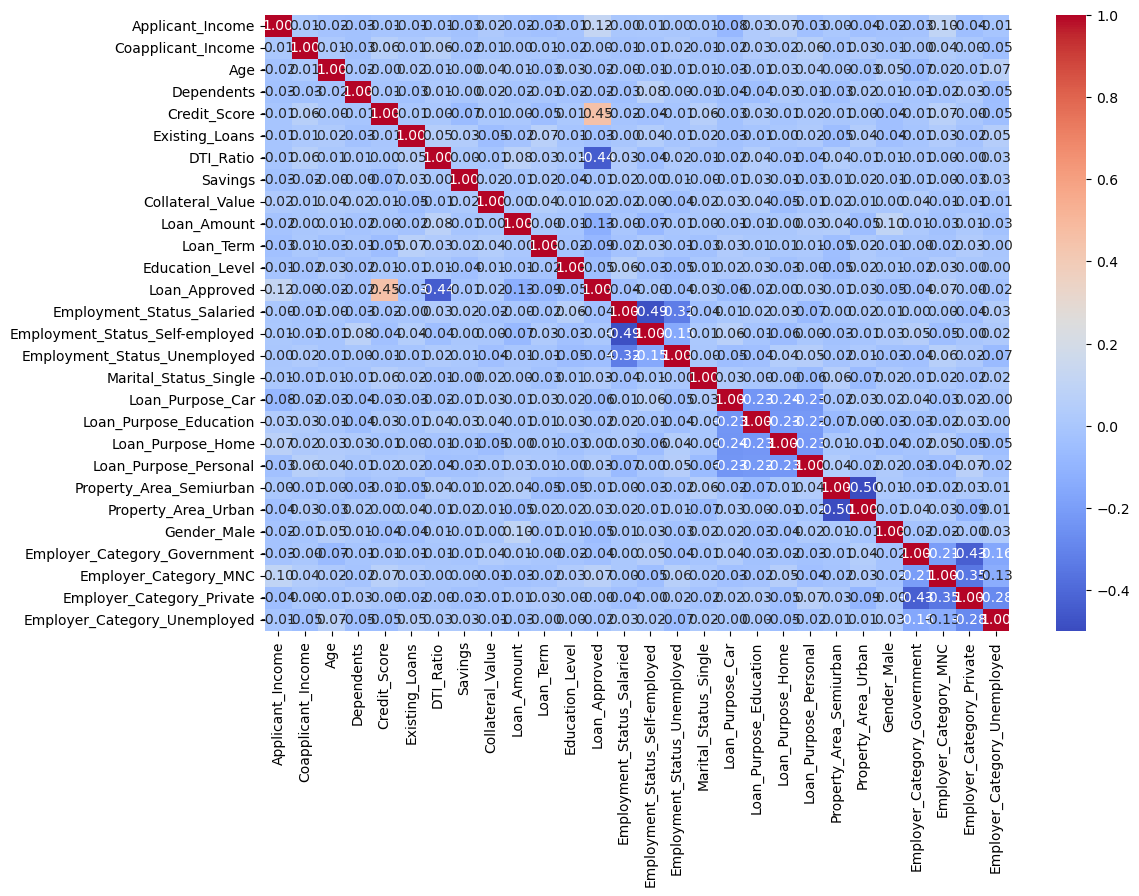

In [153]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

Train-Test_Split + feature Scaling

In [150]:
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [151]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [165]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)


train & Evalute the Model

1.logistic Regression


In [199]:
#logstical regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

model_lr = LogisticRegression(C=1.0, solver='lbfgs', random_state=42)
model_lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [200]:
y_pred = model_lr.predict(X_test_scaled)

In [201]:
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0])

In [203]:
print("accuracy score",accuracy_score(y_test,y_pred)*100,"%")
print("precision_score",precision_score(y_test,y_pred) )
print("recall_score", recall_score(y_test,y_pred) )
print("confusion_matrix",  confusion_matrix(y_test,y_pred) )

accuracy score 86.5 %
precision_score 0.7833333333333333
recall_score 0.7704918032786885
confusion_matrix [[126  13]
 [ 14  47]]


2.Naive Bayer


In [177]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train_scaled, y_train)

GaussianNB()

In [204]:
y_pred = model_NB.predict(X_test_scaled)
print("accuracy score",accuracy_score(y_test,y_pred)*100,"%")
print("precision_score",precision_score(y_test,y_pred) )
print("recall_score", recall_score(y_test,y_pred) )
print("confusion_matrix",  confusion_matrix(y_test,y_pred) )

accuracy score 86.5 %
precision_score 0.8035714285714286
recall_score 0.7377049180327869
confusion_matrix [[128  11]
 [ 16  45]]


3.KNN


In [196]:
#k=7

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

model_KNN = KNeighborsClassifier(n_neighbors=7)

model_KNN.fit(X_train_scaled, y_train)

 

KNeighborsClassifier(n_neighbors=7)

In [205]:
y_pred_knn = model_KNN.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn) * 100, "%")
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("confusion_matrix",  confusion_matrix(y_test,y_pred) )

Accuracy: 74.5 %
Precision: 0.6086956521739131
Recall: 0.45901639344262296
confusion_matrix [[128  11]
 [ 16  45]]


In [206]:
#k=5

model_KNN = KNeighborsClassifier(n_neighbors=5)

model_KNN.fit(X_train_scaled, y_train)
y_pred_knn = model_KNN.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_knn) * 100, "%")
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("confusion_matrix",  confusion_matrix(y_test,y_pred) )

Accuracy: 76.0 %
Precision: 0.6274509803921569
Recall: 0.5245901639344263
confusion_matrix [[128  11]
 [ 16  45]]


Best Model on the basis of Precision =>Navie Bayer

#feature Engineering

In [216]:
# Add or Tranform features
df["DTI_Ratio_sq"]=df["DTI_Ratio"] ** 2
df["Credit_Score_sq"]=df["Credit_Score"] **2

#to compress the skewed values
df["Applicant_Income_log"]=np.log1p(df["Applicant_Income"]) 

X=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio","Applicant_Income"])
y=df["Loan_Approved"]

#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

 

In [217]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train_scaled, y_train)
y_pred = model_NB.predict(X_test_scaled)

print("accuracy score",accuracy_score(y_test,y_pred)*100,"%")
print("precision_score",precision_score(y_test,y_pred) )
print("recall_score", recall_score(y_test,y_pred) )
print("confusion_matrix",  confusion_matrix(y_test,y_pred) )

accuracy score 86.5 %
precision_score 0.8035714285714286
recall_score 0.7377049180327869
confusion_matrix [[128  11]
 [ 16  45]]


In [218]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

model_lr = LogisticRegression(C=1.0, solver='lbfgs', random_state=42)
model_lr.fit(X_train_scaled, y_train)
print("accuracy score",accuracy_score(y_test,y_pred)*100,"%")
print("precision_score",precision_score(y_test,y_pred) )
print("recall_score", recall_score(y_test,y_pred) )
print("confusion_matrix",  confusion_matrix(y_test,y_pred) )

accuracy score 86.5 %
precision_score 0.8035714285714286
recall_score 0.7377049180327869
confusion_matrix [[128  11]
 [ 16  45]]
